## Financial Risk Analysis with Python- JP Morgan

### Pre-Requisites

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('jp_morgan_dataset.xlsx')

In [4]:
print(df.head())

   TransactionID CustomerID AccountID AccountType TransactionType  \
0              3   CUST2412  ACC80131        Loan      Withdrawal   
1             32   CUST1467  ACC74631     Current      Withdrawal   
2              9   CUST2699  ACC39482        Loan      Withdrawal   
3             42   CUST9535  ACC82947     Current      Withdrawal   
4            166   CUST7459  ACC39500      Credit         Payment   

         Product    Firm Region    Manager TransactionDate  TransactionAmount  \
0  Personal Loan  Firm C   West  Manager 3      2023-08-06        33759.69057   
1      Home Loan  Firm D  North  Manager 2      2023-11-08        69319.19933   
2    Credit Card  Firm D   West  Manager 4      2024-05-15        42831.48483   
3      Home Loan  Firm A  South  Manager 4      2023-04-30        70903.79697   
4      Home Loan  Firm D  South  Manager 4      2023-02-16        21948.97355   

   AccountBalance  RiskScore  CreditRating  TenureMonths  
0    126486.40830   0.225824           

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

## Task 1 : 
#### 1. Remove/treat any special characters or non-numeric entries from financial fields.

In [6]:
# Checking data type of all numeric fields.
print(df['AccountBalance'].dtype)
print(df['TransactionAmount'].dtype)
print(df['RiskScore'].dtype)
print(df['CreditRating'].dtype)
print(df['TenureMonths'].dtype)

float64
float64
float64
int64
int64


In [7]:
# Treated special characters or non-numeric entries from financial fields.
# Converted currency amounts into numerical format.

df['TransactionAmount'] = df['TransactionAmount'].replace('[₹$,]', '', regex=True).astype(float)
df['AccountBalance'] = df['AccountBalance'].replace('[₹$,]', '', regex=True).astype(float)
df['RiskScore'] = df['RiskScore'].astype(float)
df['TransactionAmount'] = df['TransactionAmount'].abs()

In [8]:
# Converted whole number numeric format columns (CreditRating, TenureMonths) to integer. 

df['CreditRating'] = df['CreditRating'].astype('int64')
df['TenureMonths'] = df['TenureMonths'].astype('int64')

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

In [10]:
# Validatted and Formatted (Default Format) Date Columns.
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

In [11]:
# Converted all string format columns to a single string format type (capitalized).

df['AccountType'] = df['AccountType'].str.strip().str.capitalize()
df['TransactionType'] = df['TransactionType'].str.strip().str.capitalize()
df['Product'] = df['Product'].str.strip().str.capitalize()
df['Region'] = df['Region'].str.strip().str.capitalize()
df['Manager'] = df['Manager'].str.strip().str.capitalize()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    object        
 2   AccountID          800 non-null    object        
 3   AccountType        800 non-null    object        
 4   TransactionType    800 non-null    object        
 5   Product            800 non-null    object        
 6   Firm               800 non-null    object        
 7   Region             800 non-null    object        
 8   Manager            800 non-null    object        
 9   TransactionDate    800 non-null    datetime64[ns]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMont

## Task 2:

In [13]:
# Monthly Summary using TransactionType instead of amount sign

Total_Credit_M = df[df['TransactionType'].isin(['Deposit', 'Transfer'])]\
    .groupby(df['TransactionDate'].dt.to_period('M'))['TransactionAmount'].sum().round(2)

Total_Debit_M = df[df['TransactionType'].isin(['Withdrawal', 'Payment'])]\
    .groupby(df['TransactionDate'].dt.to_period('M'))['TransactionAmount'].sum().round(2)

monthly_summary = pd.DataFrame({
    'Total_Credit': Total_Credit_M,
    'Total_Debit': Total_Debit_M.abs(),  # ensure positive display
    'Net_Transactions': Total_Credit_M - Total_Debit_M.abs()
}).round(2).fillna(0)
monthly_summary.index = monthly_summary.index.to_timestamp()
monthly_summary

,Total_Credit,Total_Debit,Net_Transactions
TransactionDate,,,
2023-01-01,1105532.23,1708184.45,-602652.22
2023-02-01,1431298.81,1336328.20,94970.61
2023-03-01,1007830.74,1520971.72,-513140.98
2023-04-01,1142478.23,1612825.21,-470346.98
2023-05-01,1576453.09,1053812.51,522640.58
2023-06-01,1487870.62,753026.33,734844.29
2023-07-01,1381409.75,1097056.78,284352.97
2023-08-01,1308379.45,864172.37,444207.08
2023-09-01,998754.98,1154629.97,-155874.99


In [14]:
# Yearly Summaries of Total Credits, Debits, and Net Transaction Volume

Total_Debit_Y = df[df['TransactionType'].isin(['Withdrawal', 'Payment'])]\
    .groupby(df['TransactionDate'].dt.to_period('Y'))['TransactionAmount'].sum().abs() 

Total_Credit_Y = df[df['TransactionType'].isin(['Deposit', 'Transfer'])]\
    .groupby(df['TransactionDate'].dt.to_period('Y'))['TransactionAmount'].sum()

yearly_summary = pd.DataFrame({
    'Total_Credit': Total_Credit_Y,
    'Total_Debit': Total_Debit_Y,
    'Net_Transactions' : Total_Credit_Y - Total_Debit_Y
}).round(2).fillna(0)
yearly_summary.index = yearly_summary.index.to_timestamp()
print(yearly_summary)

                 Total_Credit  Total_Debit  Net_Transactions
TransactionDate                                             
2023-01-01        14751985.41  15325762.35        -573776.94
2024-01-01         5232994.61   6398177.91       -1165183.30


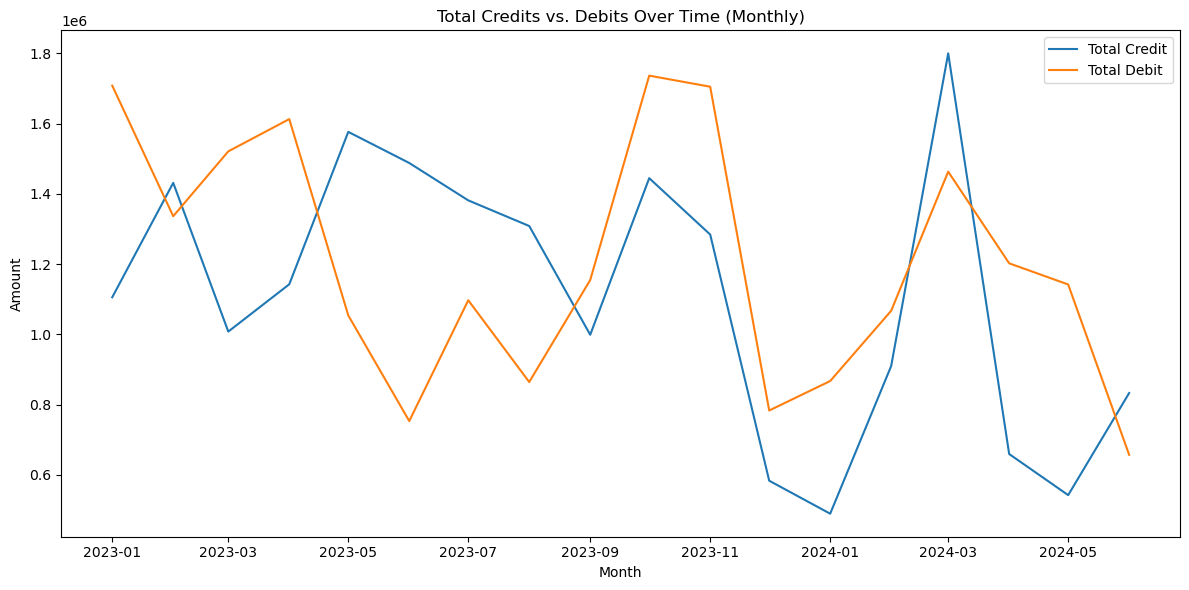

In [15]:
# Total Credit vs Debit Line Chart
plt.figure(figsize=(12, 6))

plt.plot(monthly_summary.index, monthly_summary['Total_Credit'], label='Total Credit')
plt.plot(monthly_summary.index, monthly_summary['Total_Debit'], label='Total Debit')

plt.xlabel('Month')
plt.ylabel('Amount')
plt.title('Total Credits vs. Debits Over Time (Monthly)')

plt.legend()

plt.tight_layout()
plt.show()

In [16]:
# Total Credit and Debit by Account ID
Total_Credit_Acc = df[df['TransactionType'].isin(['Deposit', 'Transfer'])]\
    .groupby(df['AccountID'])['TransactionAmount'].sum()

Total_Debit_Acc = df[df['TransactionType'].isin(['Withdrawal', 'Payment'])]\
    .groupby(df['AccountID'])['TransactionAmount'].sum()

acc_summary = pd.concat([Total_Credit_Acc, Total_Debit_Acc], axis=1)
acc_summary.columns = ['Total_Credit', 'Total_Debit']
acc_summary = acc_summary.fillna(0)

acc_summary['Net_Transactions'] = acc_summary['Total_Credit'] - acc_summary['Total_Debit']

print(acc_summary.sort_values(by='Net_Transactions'))

            Total_Credit    Total_Debit  Net_Transactions
AccountID                                                
ACC99549     2521.847520  337033.401670    -334511.554150
ACC18140    79940.845830  378278.364630    -298337.518800
ACC35419        0.000000  296560.677868    -296560.677868
ACC29477    81173.186940  375118.243063    -293945.056123
ACC61926        0.000000  231492.601132    -231492.601132
...                  ...            ...               ...
ACC75767   254145.448988       0.000000     254145.448988
ACC32627   385214.870327  103735.834410     281479.035917
ACC13357   303391.459070       0.000000     303391.459070
ACC29396   307426.228310       0.000000     307426.228310
ACC42710   430507.297050  108987.579390     321519.717660

[194 rows x 3 columns]


### Created Top 25% Quantiles and Bottom 25% Quantiles to get top and bottom performing accounts.

In [17]:
top_acc = acc_summary[acc_summary['Net_Transactions'] >= acc_summary['Net_Transactions'].quantile(0.75)]
bottom_acc = acc_summary[acc_summary['Net_Transactions'] <= acc_summary['Net_Transactions'].quantile(0.25)]

print(top_acc.sort_values(by='Net_Transactions', ascending=False))

            Total_Credit    Total_Debit  Net_Transactions
AccountID                                                
ACC42710   430507.297050  108987.579390     321519.717660
ACC29396   307426.228310       0.000000     307426.228310
ACC13357   303391.459070       0.000000     303391.459070
ACC32627   385214.870327  103735.834410     281479.035917
ACC75767   254145.448988       0.000000     254145.448988
ACC96868   236018.743680       0.000000     236018.743680
ACC22036   335813.468650  101812.702048     234000.766602
ACC92104   231854.015140       0.000000     231854.015140
ACC54589   225122.495180       0.000000     225122.495180
ACC67713   203189.357932       0.000000     203189.357932
ACC57597   254601.321180   57603.190990     196998.130190
ACC89098   182950.535820    6892.749584     176057.786236
ACC83581   241121.630610   65418.351890     175703.278720
ACC24070   249250.268890   75840.861160     173409.407730
ACC23985   172851.046310       0.000000     172851.046310
ACC49422   172

In [18]:
print(bottom_acc.sort_values(by='Net_Transactions', ascending=True))

            Total_Credit    Total_Debit  Net_Transactions
AccountID                                                
ACC99549     2521.847520  337033.401670    -334511.554150
ACC18140    79940.845830  378278.364630    -298337.518800
ACC35419        0.000000  296560.677868    -296560.677868
ACC29477    81173.186940  375118.243063    -293945.056123
ACC61926        0.000000  231492.601132    -231492.601132
ACC53865        0.000000  230206.154870    -230206.154870
ACC58078    28941.096570  246152.803390    -217211.706820
ACC88252        0.000000  214240.279110    -214240.279110
ACC55331   120333.682264  329665.651130    -209331.968866
ACC67701     6808.226060  202514.331970    -195706.105910
ACC25811    50430.709320  245265.284590    -194834.575270
ACC41829        0.000000  187145.679730    -187145.679730
ACC26026    31867.498050  218871.467380    -187003.969330
ACC38559        0.000000  185394.121920    -185394.121920
ACC62809        0.000000  185287.349940    -185287.349940
ACC66190      

In [19]:
df = df.sort_values(['AccountID', 'TransactionDate'])
df['Gap'] = df.groupby('AccountID')['TransactionDate'].diff()
df['Dormant'] = df['Gap'] >= pd.Timedelta(days=60)

dormant_acc = df.groupby('AccountID')['Dormant'].max().reset_index()

print(dormant_acc)

    AccountID  Dormant
0    ACC10117    False
1    ACC10996     True
2    ACC11062     True
3    ACC11188     True
4    ACC11285     True
..        ...      ...
189  ACC97225     True
190  ACC97411     True
191  ACC99117     True
192  ACC99409    False
193  ACC99549     True

[194 rows x 2 columns]


## Task 3

### Account Segmentation (No. of Transactions): 
### Low (1 to 3), 
### Medium (4 to 7) and 
### High (8 to 10)

In [20]:
# Segmented customers by transaction volume.

def segment_volume(volume):
    if volume < 4 and volume > 0 :
        return 'Low Volume'
    elif volume < 8  and volume >= 4: 
        return 'Medium Volume'
    else : 
        return 'High Volume'

In [21]:
txn_freq = df.groupby('AccountID').size().reset_index(name='TransactionVolume')
txn_freq['TxnVolumeSegment'] = txn_freq['TransactionVolume'].apply(segment_volume)
print(txn_freq.sort_values(by='TransactionVolume').tail(20))

    AccountID  TransactionVolume TxnVolumeSegment
54   ACC30852                  7    Medium Volume
66   ACC35419                  7    Medium Volume
121  ACC62446                  7    Medium Volume
17   ACC18140                  7    Medium Volume
36   ACC25811                  7    Medium Volume
23   ACC21429                  7    Medium Volume
158  ACC81631                  7    Medium Volume
79   ACC42710                  7    Medium Volume
180  ACC92360                  8      High Volume
159  ACC82298                  8      High Volume
26   ACC22036                  8      High Volume
100  ACC50817                  8      High Volume
164  ACC83269                  8      High Volume
118  ACC60432                  9      High Volume
110  ACC55331                  9      High Volume
50   ACC29477                  9      High Volume
51   ACC29646                  9      High Volume
85   ACC45907                 10      High Volume
103  ACC51593                 10      High Volume


In [22]:
# Segmented customers by average balance.

avg_balance = df.groupby('AccountID')['AccountBalance'].mean().reset_index(name='AvgBalance')

txn_freq = txn_freq.merge(avg_balance, on='AccountID')
print(txn_freq.sort_values(by='AvgBalance'))

    AccountID  TransactionVolume TxnVolumeSegment     AvgBalance
192  ACC99409                  2       Low Volume   32962.941265
42   ACC28292                  1       Low Volume   37550.014430
97   ACC49422                  3       Low Volume   38841.595410
113  ACC57597                  5    Medium Volume   39875.536866
109  ACC54589                  3       Low Volume   42538.305527
..        ...                ...              ...            ...
6    ACC12182                  4    Medium Volume  111954.461552
90   ACC47099                  3       Low Volume  114288.335133
71   ACC39482                  1       Low Volume  123007.435300
179  ACC92104                  2       Low Volume  123092.693350
18   ACC18177                  1       Low Volume  166805.957700

[194 rows x 4 columns]


### Account Segmentation (Average Balance): 
### Low (< 50,000), 
### Medium (>= 50,000 and < 1,00,000) and 
### High (>= 1,00,000)

In [23]:
def segment_balance(balance):
    if balance >= 100000:
        return 'High Balance'
    elif balance < 100000 and balance >= 50000:
        return 'Medium Balance'
    else : 
        return 'Low Balance'


In [24]:
txn_freq['AvgBalanceSegment'] = txn_freq['AvgBalance'].apply(segment_balance)

txn_freq

,AccountID,TransactionVolume,TxnVolumeSegment,AvgBalance,AvgBalanceSegment
0,ACC10117,1,Low Volume,90780.256640,Medium Balance
1,ACC10996,4,Medium Volume,64046.568590,Medium Balance
2,ACC11062,4,Medium Volume,62784.100737,Medium Balance
3,ACC11188,3,Low Volume,80558.926400,Medium Balance
4,ACC11285,6,Medium Volume,95745.546255,Medium Balance
...,...,...,...,...,...
189,ACC97225,5,Medium Volume,80994.270410,Medium Balance
190,ACC97411,6,Medium Volume,61783.633875,Medium Balance
191,ACC99117,6,Medium Volume,80478.450622,Medium Balance
192,ACC99409,2,Low Volume,32962.941265,Low Balance


In [25]:
top_10_quantile = acc_summary['Net_Transactions'].quantile(0.90)
top_net_inflow_acc = acc_summary[acc_summary['Net_Transactions'] >= top_10_quantile]

top_net_inflow_acc.sort_values(by='Net_Transactions',ascending=False)


,Total_Credit,Total_Debit,Net_Transactions
AccountID,,,
ACC42710,430507.297050,108987.579390,321519.717660
ACC29396,307426.228310,0.000000,307426.228310
ACC13357,303391.459070,0.000000,303391.459070
ACC32627,385214.870327,103735.834410,281479.035917
ACC75767,254145.448988,0.000000,254145.448988
ACC96868,236018.743680,0.000000,236018.743680
ACC22036,335813.468650,101812.702048,234000.766602
ACC92104,231854.015140,0.000000,231854.015140
ACC54589,225122.495180,0.000000,225122.495180


In [26]:
# Created Combined Profile Dataset.

# Net inflow
credit = df[df['TransactionType'].isin(['Deposit', 'Transfer'])] \
    .groupby('AccountID')['TransactionAmount'].sum()

debit = df[df['TransactionType'].isin(['Withdrawal', 'Payment'])] \
    .groupby('AccountID')['TransactionAmount'].sum()

net_flow = (credit - debit).reset_index(name='NetFlow')

# Transaction frequency
txn_freq = df.groupby('AccountID')['TransactionID'].count().reset_index(name='TxnFrequency')

# Average balance
avg_balance = df.groupby('AccountID')['AccountBalance'].mean().reset_index(name='AvgBalance')

# Merge all
profile_df = net_flow.merge(txn_freq, on='AccountID') \
                     .merge(avg_balance, on='AccountID')

profile_df

,AccountID,NetFlow,TxnFrequency,AvgBalance
0,ACC10117,NaN,1,90780.256640
1,ACC10996,124107.378684,4,64046.568590
2,ACC11062,64029.649680,4,62784.100737
3,ACC11188,NaN,3,80558.926400
4,ACC11285,-137316.854010,6,95745.546255
...,...,...,...,...
189,ACC97225,13046.457258,5,80994.270410
190,ACC97411,141972.895730,6,61783.633875
191,ACC99117,-11401.515830,6,80478.450622
192,ACC99409,NaN,2,32962.941265


In [27]:
# Defined thresholds using quantiles
# Used 0.75 quantile to identify TOP 25% accounts (high values)
high_inflow_threshold = profile_df['NetFlow'].quantile(0.75)
high_freq_threshold = profile_df['TxnFrequency'].quantile(0.75)

# Used 0.25 quantile to identify BOTTOM 25% accounts (low values)
low_balance_threshold = profile_df['AvgBalance'].quantile(0.25)

# Used 0.05 quantile to identify extreme low / near-zero balance accounts (bottom 5%)
near_zero_threshold = profile_df['AvgBalance'].quantile(0.05)

# Assign customer segments
profile_df['Segment'] = 'Normal'

# High net inflow accounts
profile_df.loc[
    profile_df['NetFlow'] >= high_inflow_threshold,
    'Segment'
] = 'High Net Inflow'

# High transaction frequency but low balance
profile_df.loc[
    (profile_df['TxnFrequency'] >= high_freq_threshold) &
    (profile_df['AvgBalance'] <= low_balance_threshold),
    'Segment'
] = 'High Frequency Low Balance'

# Near zero or negative balance accounts
profile_df.loc[
    profile_df['AvgBalance'] <= near_zero_threshold,
    'Segment'
] = 'Near Zero / Negative Balance'

profile_df[['AccountID', 'NetFlow', 'TxnFrequency', 'AvgBalance', 'Segment']]

,AccountID,NetFlow,TxnFrequency,AvgBalance,Segment
0,ACC10117,NaN,1,90780.256640,Normal
1,ACC10996,124107.378684,4,64046.568590,High Net Inflow
2,ACC11062,64029.649680,4,62784.100737,Normal
3,ACC11188,NaN,3,80558.926400,Normal
4,ACC11285,-137316.854010,6,95745.546255,Normal
...,...,...,...,...,...
189,ACC97225,13046.457258,5,80994.270410,Normal
190,ACC97411,141972.895730,6,61783.633875,High Frequency Low Balance
191,ACC99117,-11401.515830,6,80478.450622,Normal
192,ACC99409,NaN,2,32962.941265,Near Zero / Negative Balance


## Task 4:

In [28]:
# Identified large withdrawals
withdrawals = df[df['TransactionType'].isin(['Withdrawal', 'Payment'])]

# Using 0.25 quantile to capture large withdrawals
large_withdrawal_threshold = withdrawals['TransactionAmount'].quantile(0.75)

large_withdrawals = withdrawals[
    withdrawals['TransactionAmount'] <= large_withdrawal_threshold
]

# Number of large withdrawals per account
large_withdraw_freq = large_withdrawals.groupby('AccountID').size().reset_index(name='LargeWithdrawalCount')

In [29]:
# Identified frequent large withdrawals using top 25%
freq_threshold = large_withdraw_freq['LargeWithdrawalCount'].quantile(0.75)

frequent_large_withdrawers = large_withdraw_freq[
    large_withdraw_freq['LargeWithdrawalCount'] >= freq_threshold
]

print(frequent_large_withdrawers)

    AccountID  LargeWithdrawalCount
2    ACC11188                     3
6    ACC15228                     3
9    ACC15925                     4
14   ACC18140                     3
17   ACC19178                     3
18   ACC20297                     4
19   ACC21264                     3
20   ACC21429                     3
22   ACC21878                     4
23   ACC22036                     3
29   ACC25132                     3
30   ACC25811                     3
32   ACC26940                     4
35   ACC28295                     3
41   ACC29477                     6
42   ACC29646                     3
45   ACC30852                     4
46   ACC31539                     3
52   ACC34119                     3
55   ACC34821                     3
57   ACC35419                     5
58   ACC36079                     3
68   ACC42467                     3
72   ACC45101                     3
73   ACC45907                     5
79   ACC49140                     3
82   ACC50817               

In [30]:
# Identified overdraft accounts (negative balance)
overdraft_accounts = df[df['AccountBalance'] < 0]

overdraft_flag = overdraft_accounts.groupby('AccountID').size().reset_index(name='OverdraftCount')

In [31]:
# Combined risk indicators
risk_df = frequent_large_withdrawers.merge(
    overdraft_flag,
    on='AccountID',
    how='outer'
)
risk_df = risk_df.fillna(0)

# Assigned risk labels
risk_df['RiskFlag'] = 'Normal'

risk_df.loc[
    risk_df['LargeWithdrawalCount'] > 0,
    'RiskFlag'
] = 'Frequent Large Withdrawals'

risk_df.loc[
    risk_df['OverdraftCount'] > 0,
    'RiskFlag'
] = 'Overdraft Risk'
risk_df

,AccountID,LargeWithdrawalCount,OverdraftCount,RiskFlag
0,ACC11188,3.0,0.0,Frequent Large Withdrawals
1,ACC15228,3.0,0.0,Frequent Large Withdrawals
2,ACC15925,4.0,0.0,Frequent Large Withdrawals
3,ACC18140,3.0,0.0,Frequent Large Withdrawals
4,ACC19178,3.0,0.0,Frequent Large Withdrawals
5,ACC20297,4.0,0.0,Frequent Large Withdrawals
6,ACC21264,3.0,0.0,Frequent Large Withdrawals
7,ACC21429,3.0,0.0,Frequent Large Withdrawals
8,ACC21878,4.0,0.0,Frequent Large Withdrawals
9,ACC22036,3.0,0.0,Frequent Large Withdrawals


In [32]:
# Calculated balance volatility using Coefficient of Variation (CV)
task4_df = df.groupby('AccountID')['AccountBalance'].agg(
    BalanceStd='std',
    MeanBalance='mean'
).reset_index()

task4_df['CV'] = task4_df['BalanceStd'] / task4_df['MeanBalance']
task4_df = task4_df.fillna(0)
task4_df

,AccountID,BalanceStd,MeanBalance,CV
0,ACC10117,0.000000,90780.256640,0.000000
1,ACC10996,30390.798000,64046.568590,0.474511
2,ACC11062,37598.383500,62784.100737,0.598852
3,ACC11188,33781.833882,80558.926400,0.419343
4,ACC11285,42139.172552,95745.546255,0.440116
...,...,...,...,...
189,ACC97225,33590.603117,80994.270410,0.414728
190,ACC97411,34715.818903,61783.633875,0.561893
191,ACC99117,28817.571181,80478.450622,0.358078
192,ACC99409,30169.327975,32962.941265,0.915250


In [33]:
# Detected anomalies using IQR method
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

anomalies_iqr = df[
    (df['TransactionAmount'] < lower_bound) |
    (df['TransactionAmount'] > upper_bound)
]
anomalies_iqr

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Gap,Dormant
129,161,CUST4373,ACC41829,Current,Payment,Savings account,Firm A,North,Manager 3,2024-03-22,135972.3439,42302.00951,-0.368537,469,175,NaT,False
727,163,CUST1747,ACC92104,Savings,Deposit,Savings account,Firm A,West,Manager 1,2023-08-06,147447.2951,101759.29850,0.099626,421,86,NaT,False
242,86,CUST7855,ACC95164,Savings,Payment,Home loan,Firm C,North,Manager 3,2023-10-26,143067.1846,73627.79044,0.752617,582,226,164 days,True
115,122,CUST8344,ACC99117,Credit,Withdrawal,Home loan,Firm B,East,Manager 4,2024-01-29,129471.4656,73117.85560,0.186813,820,210,17 days,False


In [34]:
# Number of Anomalies per account
anomaly_count = anomalies_iqr.groupby('AccountID').size().reset_index(name='AnomalyCount')

# Count anomalies per account
anomaly_summary = anomalies_iqr.groupby('AccountID').size().reset_index(name='Anomaly_Frequency')
    
# Created Volatility flag dataset using Quantile method
volatility_flag = task4_df[['AccountID', 'CV']].copy()

# Used 0.75 quantile to identify high volatility accounts (top 25%)
cv_threshold = volatility_flag['CV'].quantile(0.75)

# Flagged high volatility accounts
volatility_flag['HighVolatility'] = volatility_flag['CV'] >= cv_threshold

volatility_flag

,AccountID,CV,HighVolatility
0,ACC10117,0.000000,False
1,ACC10996,0.474511,False
2,ACC11062,0.598852,True
3,ACC11188,0.419343,False
4,ACC11285,0.440116,False
...,...,...,...
189,ACC97225,0.414728,False
190,ACC97411,0.561893,True
191,ACC99117,0.358078,False
192,ACC99409,0.915250,True


In [35]:
# Calculated large withdrawals using Quantile Method
withdrawals = df[df['TransactionType'].isin(['Withdrawal', 'Payment'])]
threshold = withdrawals['TransactionAmount'].quantile(0.25)
large_withdrawals = withdrawals[
    withdrawals['TransactionAmount'] <= threshold
]

# Number of large withdrawals per account
withdraw_flag = large_withdrawals.groupby('AccountID').size().reset_index(name='LargeWithdrawCount')
withdraw_flag

,AccountID,LargeWithdrawCount
0,ACC11188,1
1,ACC12182,1
2,ACC12334,2
3,ACC15671,1
4,ACC15925,2
...,...,...
77,ACC89098,1
78,ACC92360,1
79,ACC94242,1
80,ACC97225,3


In [36]:
# Prepared CV data
cv_data = task4_df[['AccountID', 'CV']]

# Used previous task's anomalies detecter
iqr_flags = anomalies_iqr

# Number of anomalies frequency per account
anomaly_summary = (
    iqr_flags.groupby('AccountID')
    .size()
    .reset_index(name='Anomaly_Frequency')
)

# Merge anomaly and volatility data
risk_profile = anomaly_summary.merge(cv_data, on='AccountID', how='left')

# Identified accounts with negative balances
negative_balance = (
    df[df['AccountBalance'] < 0]
    .groupby('AccountID')
    .size()
    .reset_index(name='NegativeBalanceCount')
)

# Merged negative balance info
risk_profile = risk_profile.merge(negative_balance, on='AccountID', how='left')
risk_profile['NegativeBalanceCount'] = risk_profile['NegativeBalanceCount'].fillna(0)


# Used0 0.75 quantile to identify high volatility accounts
cv_threshold = risk_profile['CV'].quantile(0.75)


# Final risk flag based on multiple conditions
risk_profile['RiskFlag'] = (
    (risk_profile['Anomaly_Frequency'] >= 2) |
    (risk_profile['CV'] >= cv_threshold) |
    (risk_profile['NegativeBalanceCount'] > 0)
)

# Filter suspicious accounts
suspicious_accounts = risk_profile[risk_profile['RiskFlag'] == True]

suspicious_accounts

,AccountID,Anomaly_Frequency,CV,NegativeBalanceCount,RiskFlag
0,ACC41829,1,0.484036,0.0,True


# Task 5:

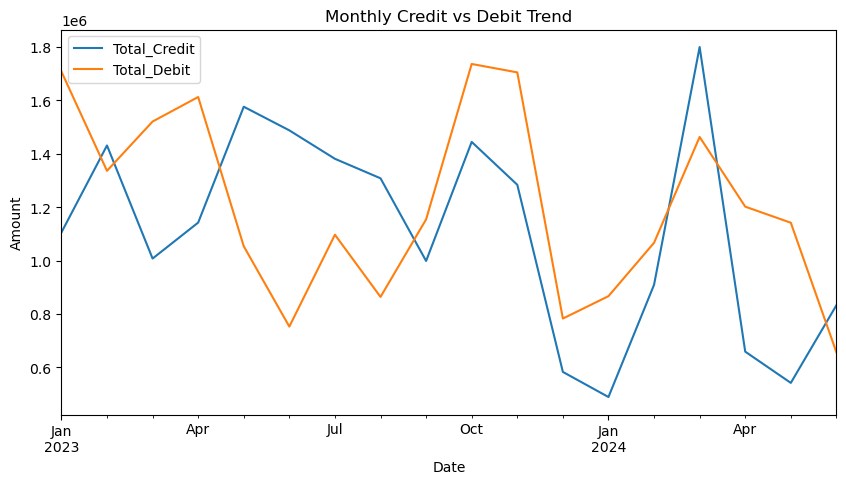

In [37]:
# 1. Monthly Credit vs Debit Trend
# Line chart to analyze how total credits and debits change over time
monthly_summary[['Total_Credit', 'Total_Debit']].plot(figsize=(10,5))

# Title and labels
plt.title('Monthly Credit vs Debit Trend')
plt.xlabel('Date')
plt.ylabel('Amount')

# Display the chart
plt.show()

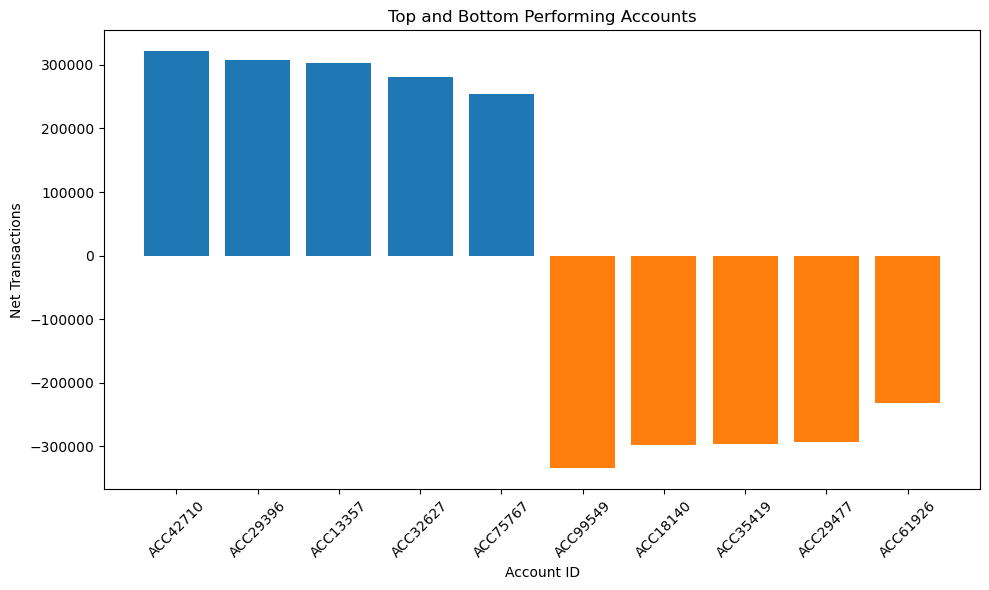

In [38]:
# 2. Top and Bottom Performing Accounts
# Select top 5 and bottom 5 accounts based on net transactions
top_5 = top_acc.sort_values(by='Net_Transactions', ascending=False).head(5)
bottom_5 = bottom_acc.sort_values(by='Net_Transactions', ascending=True).head(5)

# Bar chart to compare top and bottom accounts
plt.figure(figsize=(10,6))

plt.bar(top_5.index.astype(str), top_5['Net_Transactions'])
plt.bar(bottom_5.index.astype(str), bottom_5['Net_Transactions'])

# Labels and title
plt.xlabel('Account ID')
plt.ylabel('Net Transactions')
plt.title('Top and Bottom Performing Accounts')

# Rotate labels for readability
plt.xticks(rotation=45)
plt.tight_layout()

# Display the chart
plt.show()


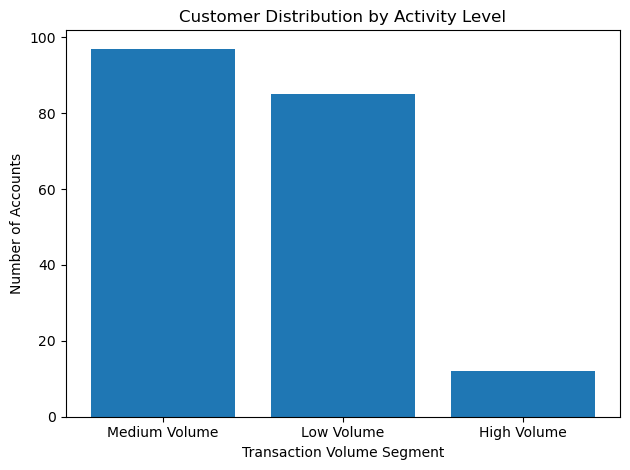

In [39]:
# 3. Customer Distribution by Activity Level
# Group accounts by number of transactions
txn_freq = df.groupby('AccountID').size().reset_index(name='TransactionVolume')

# Assign activity segments (Low, Medium, High)
txn_freq['TxnVolumeSegment'] = txn_freq['TransactionVolume'].apply(segment_volume)

# Count number of accounts in each segment
segment_counts = txn_freq['TxnVolumeSegment'].value_counts()

# Bar chart for distribution
plt.figure()

plt.bar(segment_counts.index, segment_counts.values)

# Labels and title
plt.xlabel('Transaction Volume Segment')
plt.ylabel('Number of Accounts')
plt.title('Customer Distribution by Activity Level')

plt.tight_layout()
plt.show()


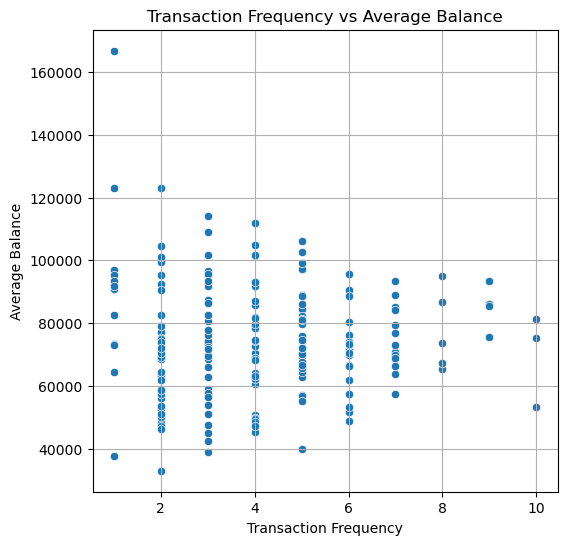

In [40]:
# 4. Transaction Frequency vs Average Balance (Behavior Analysis)
# Scatter plot to analyze relationship between frequency and balance
plt.figure(figsize=(6,6))

sns.scatterplot(
    x=profile_df['TxnFrequency'], 
    y=profile_df['AvgBalance']
)

# Labels and title
plt.title('Transaction Frequency vs Average Balance')
plt.xlabel('Transaction Frequency')
plt.ylabel('Average Balance')

# Grid for better readability
plt.grid()

# Display plot
plt.show()


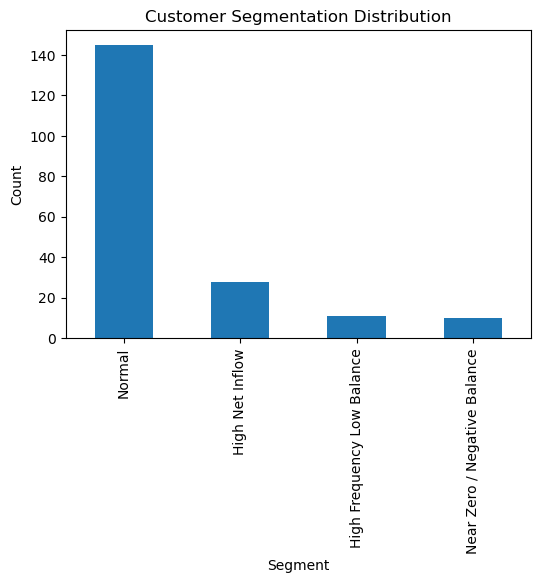

In [41]:
# 5. Customer Segmentation Distribution
# Count number of customers in each segment
plt.figure(figsize=(6,4))
profile_df['Segment'].value_counts().plot(kind='bar')

# Labels and title
plt.title('Customer Segmentation Distribution')
plt.xlabel('Segment')
plt.ylabel('Count')

# Display chart
plt.show()

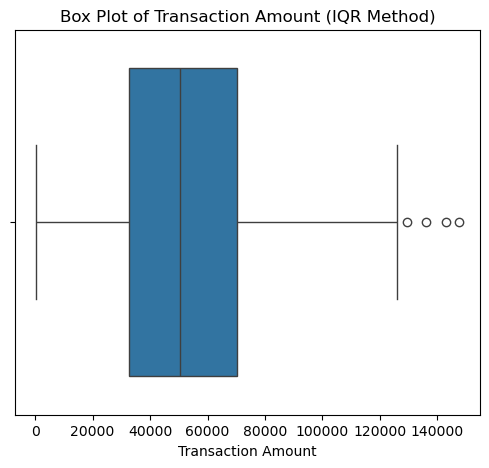

In [42]:
# 6. Box Plot (IQR Method for Anomaly Detection)
# Plot to identify outliers in transaction amounts
plt.figure(figsize=(6,5))

sns.boxplot(x=df['TransactionAmount'])

# Labels and title
plt.title('Box Plot of Transaction Amount (IQR Method)')
plt.xlabel('Transaction Amount')

# Display plot
plt.show()

Text(0, 0.5, 'Frequency')

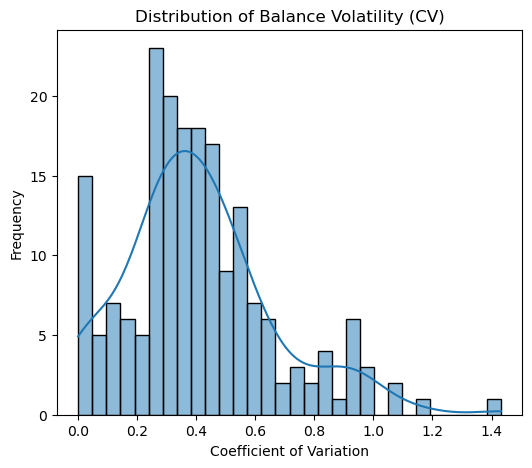

In [43]:
# 7. Distribution of Balance Volatility (CV)
# Histogram with KDE to analyze volatility distribution
plt.figure(figsize=(6,5))

sns.histplot(task4_df['CV'], bins=30, kde=True)

# Labels and title
plt.title('Distribution of Balance Volatility (CV)')
plt.xlabel('Coefficient of Variation')
plt.ylabel('Frequency')

## Task 6

In [44]:
# Step 1: Divide accounts into High and Low transaction groups using median
median_freq = profile_df['TxnFrequency'].median()

profile_df['TxnSegment'] = profile_df['TxnFrequency'].apply(
    lambda x: 'High' if x > median_freq else 'Low'
)

# Display updated dataframe
profile_df

,AccountID,NetFlow,TxnFrequency,AvgBalance,Segment,TxnSegment
0,ACC10117,NaN,1,90780.256640,Normal,Low
1,ACC10996,124107.378684,4,64046.568590,High Net Inflow,Low
2,ACC11062,64029.649680,4,62784.100737,Normal,Low
3,ACC11188,NaN,3,80558.926400,Normal,Low
4,ACC11285,-137316.854010,6,95745.546255,Normal,High
...,...,...,...,...,...,...
189,ACC97225,13046.457258,5,80994.270410,Normal,High
190,ACC97411,141972.895730,6,61783.633875,High Frequency Low Balance,High
191,ACC99117,-11401.515830,6,80478.450622,Normal,High
192,ACC99409,NaN,2,32962.941265,Near Zero / Negative Balance,Low


In [45]:
# Step 2: Extract average balance for both groups
high_vol = profile_df[profile_df['TxnSegment'] == 'High']['AvgBalance']
low_vol = profile_df[profile_df['TxnSegment'] == 'Low']['AvgBalance']

In [46]:
# Step 3: Define hypotheses
# H0 (Null Hypothesis): High-volume accounts do NOT have higher average balance
# H1 (Alternative Hypothesis): High-volume accounts have higher average balance

# Compare mean values
print("Mean High Volume:", high_vol.mean())
print("Mean Low Volume:", low_vol.mean())

Mean High Volume: 74570.68405488349
Mean Low Volume: 74881.04143572757


In [47]:
# Step 4: Perform T-test
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_vol, low_vol)

# Print p-value
print("P-value:", p_value)

P-value: 0.9093050009313017


In [48]:
# Step 5: Decision making based on significance level
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


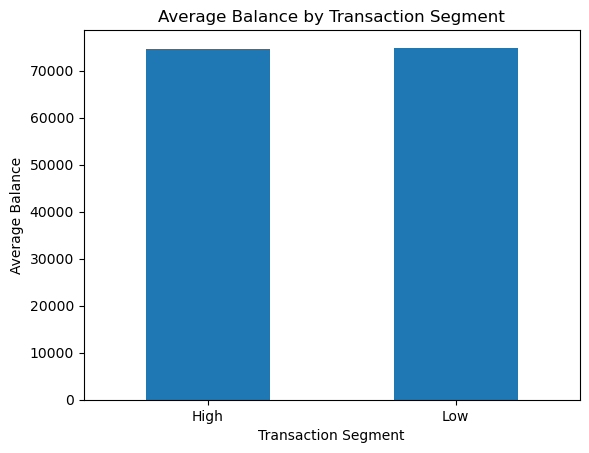

In [49]:
# Plotting Mean Balance Comparison.

group_means = profile_df.groupby('TxnSegment')['AvgBalance'].mean()

group_means.plot(kind='bar')
plt.title('Average Balance by Transaction Segment')
plt.xlabel('Transaction Segment')
plt.ylabel('Average Balance')
plt.xticks(rotation=0)
plt.show()